# lego_beyond_tier2_access.pddl

In [ ]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import mujoco
from IPython.display import display as ipy_display
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

from yaml_loader import load_task
from scenes import SimpleLegoScene
from bridges import LegoCoarseSimpleSLSBridge, LegoCoarseSimpleV2SLSBridge, execute_plan

## Visualization Helpers

In [2]:
def _free_cam(env, lookat, distance, azimuth, elevation):
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultFreeCamera(env.get_model(), cam)
    cam.lookat[:] = np.asarray(lookat, float)
    cam.distance, cam.azimuth, cam.elevation = distance, azimuth, elevation
    return cam

def _render(env, cam, width=640, height=480):
    env.forward(); r = mujoco.Renderer(env.get_model(), height=height, width=width)
    r.update_scene(env.get_data(), camera=cam); img = r.render(); r.close(); return img

def _show(img, title):
    fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(img); ax.axis("off")
    ax.set_title(title, fontsize=10); fig.tight_layout(); ipy_display(fig); plt.close(fig)

def ee_position(env):
    sid = mujoco.mj_name2id(env.get_model(), mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
    env.forward(); return env.get_data().site_xpos[sid].copy()

def show_scene(env, title="Scene", distance=1.3, azimuth=135, elevation=-25, center=None):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center, distance, azimuth, elevation)), title)

def show_top_view(env, center=None, distance=0.75, title="Top-down view"):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center, distance, 90, -89)), title)

def show_ee_top_view(env, distance=0.35, title="End-effector (top-down)"):
    show_top_view(env, ee_position(env), distance, title)

def show_object_top_view(env, name, distance=0.22, title=None):
    show_top_view(env, env.get_object_position(name), distance, title or f"{name} (top-down)")

print("Visualisation helpers ready \u2713")

Visualisation helpers ready ✓


In [3]:
SEED = 42
TASK = "dataset/ground_truth/tier3/task_018.yaml"  # task previously failed
bricks, lat = load_task(TASK, TASK)
scene = SimpleLegoScene(bricks, seed=42)
scene.env.ik.solver = "daqp"
_table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above
bricks

[Brick(name='2x2_brick_1', type='brick_2x2', color='green', layer=0, yaw=90, cells=frozenset({(0, 8), (1, 8), (0, 9), (1, 9)}), anchor=(0, 8), center=(0.016, 0.148, 0.0), initial=(0.25, -0.2198, 0.0495), initial_yaw=0),
 Brick(name='4x2_brick_2', type='brick_4x2', color='red', layer=0, yaw=90, cells=frozenset({(-2, 11), (-1, 11), (-1, 12), (-2, 10), (-1, 10), (-1, 9), (-2, 9), (-2, 12)}), anchor=(-2, 9), center=(-0.016, 0.18, 0.0), initial=(0.4892, -0.2033, 0.0495), initial_yaw=0),
 Brick(name='2x2_brick_3', type='brick_2x2', color='green', layer=0, yaw=90, cells=frozenset({(2, 9), (2, 10), (3, 9), (3, 10)}), anchor=(2, 9), center=(0.048, 0.164, 0.0), initial=(0.3812, -0.1221, 0.0495), initial_yaw=0),
 Brick(name='2x2_brick_4', type='brick_2x2', color='green', layer=1, yaw=90, cells=frozenset({(1, 9), (0, 9), (0, 10), (1, 10)}), anchor=(0, 9), center=(0.016, 0.164, 0.0191), initial=(0.4909, -0.1302, 0.0495), initial_yaw=0),
 Brick(name='4x2_brick_5', type='brick_4x2', color='green', la

objects: {'brick': ['b_2x2_brick_1', 'b_4x2_brick_2', 'b_2x2_brick_3', 'b_2x2_brick_4', 'b_4x2_brick_5', 'b_2x2_brick_6', 'b_4x2_brick_7', 'b_2x2_brick_8', 'filler_1', 'filler_2', 'filler_3', 'filler_4', 'filler_5', 'gap_1', 'gap_2', 'gap_3']}
goals:   [('at-target', 'b_2x2_brick_1'), ('at-target', 'b_4x2_brick_2'), ('at-target', 'b_2x2_brick_3'), ('at-target', 'b_2x2_brick_4'), ('at-target', 'b_4x2_brick_5'), ('at-target', 'b_2x2_brick_6'), ('at-target', 'b_4x2_brick_7'), ('at-target', 'b_2x2_brick_8')]


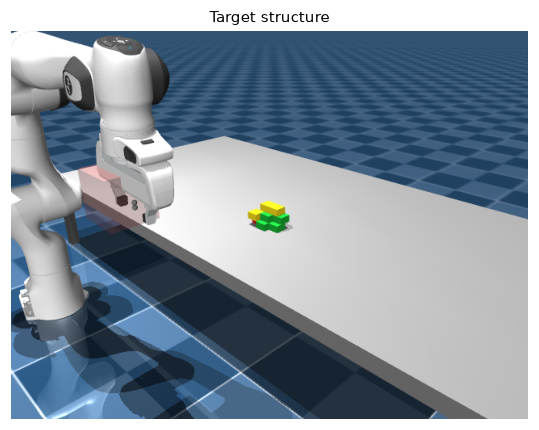

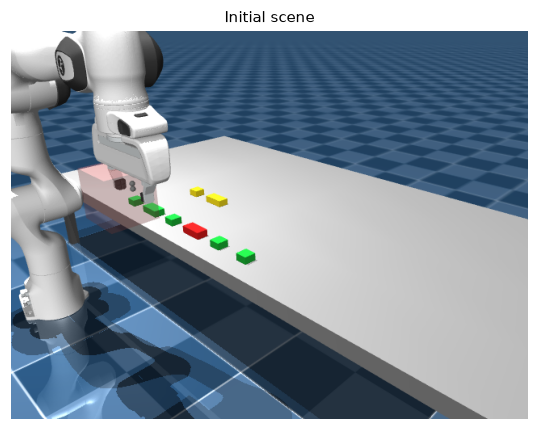

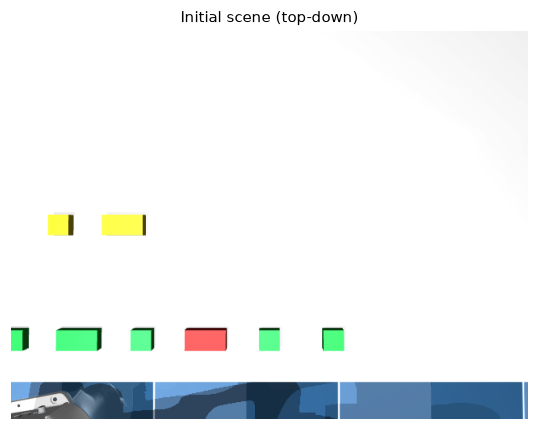

NOTE: To disable printing of planning engine credits, add this line to your code: `up.shortcuts.get_environment().credits_stream = None`
  *** Credits ***
  * In operation mode `OneshotPlanner` at line 395 of `/Users/maxazvd/uni/sem3/aifr/lego-workbenchmark/lego-workbenchmark/src/tampanda/tamp/domain_bridge.py`, you are using the following planning engine:
  * Engine name: pyperplan
  * Developers:  Albert-Ludwigs-Universität Freiburg (Yusra Alkhazraji, Matthias Frorath, Markus Grützner, Malte Helmert, Thomas Liebetraut, Robert Mattmüller, Manuela Ortlieb, Jendrik Seipp, Tobias Springenberg, Philip Stahl, Jan Wülfing)
  * Description: Pyperplan is a lightweight STRIPS planner written in Python.

Planned for 0.158s

PLAN:
  ('prepare_place', ('b_4x2_brick_2', 'filler_1', 'filler_2', 'filler_3', 'filler_4', 'filler_5'))
  ('prepare_place', ('b_2x2_brick_3', 'filler_1', 'filler_2', 'filler_3', 'filler_4', 'filler_5'))
  ('prepare_place', ('b_2x2_brick_1', 'filler_1', 'filler_2', 'filler_3

In [4]:
from bridges import LegoBeyondTier2AccessSLSWeldBridge

bb = LegoBeyondTier2AccessSLSWeldBridge()
# try new domain/bridge
bridge = bb.make_bridge("domains/lego_beyond_tier2_access.pddl", scene)
objects, goals = bb.build_objects_and_goal(bricks)
print("objects:", objects)
print("goals:  ", goals)


scene.to_target_structure()
show_scene(scene.env, "Target structure")
scene.env.reset()
# scene.env.rest(1.0)

show_scene(scene.env, "Initial scene")
show_top_view(scene.env, title="Initial scene (top-down)")

start_t = time.time()
plan = bridge.plan(objects, goals)
wall_time = time.time() - start_t
print(f"Planned for {wall_time:.3f}s")
print("\nPLAN:")
for step in plan:
    print(" ", step)

[1/24] prepare_place(b_4x2_brick_2, filler_1, filler_2, filler_3, filler_4, filler_5) -> ok


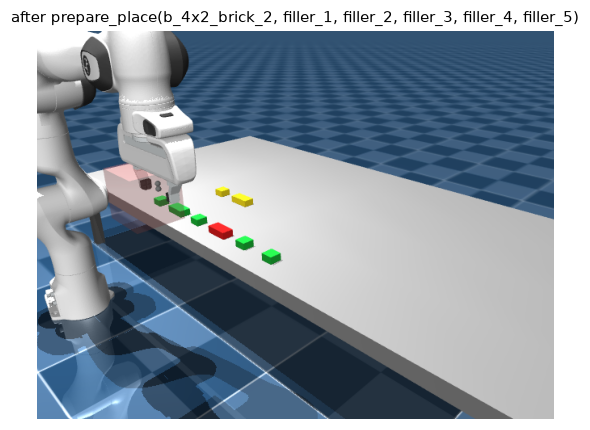

[2/24] prepare_place(b_2x2_brick_3, filler_1, filler_2, filler_3, filler_4, filler_5) -> ok


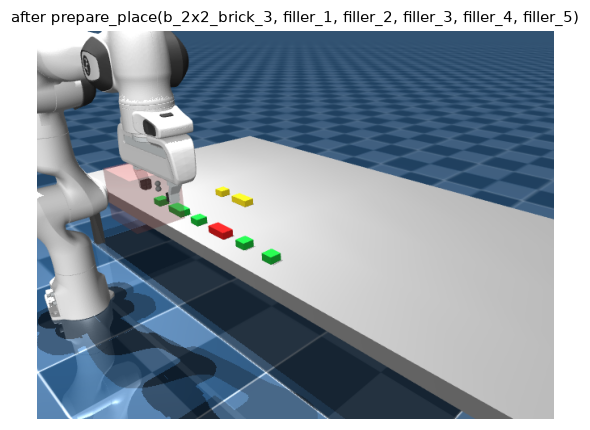

[3/24] prepare_place(b_2x2_brick_1, filler_1, filler_2, filler_3, filler_4, filler_5) -> ok


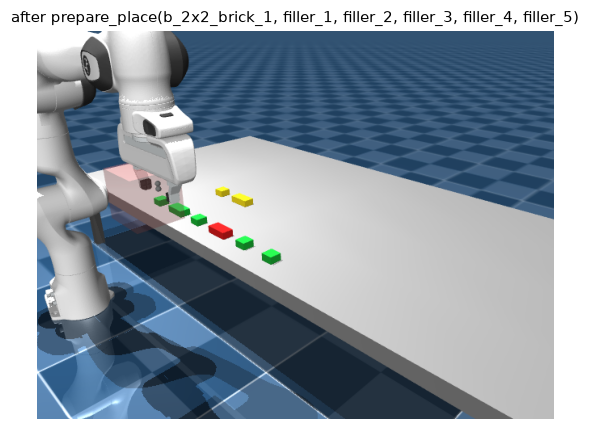

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.1 mm
  pick SUCCESS
[4/24] pick_x(b_4x2_brick_2) -> ok


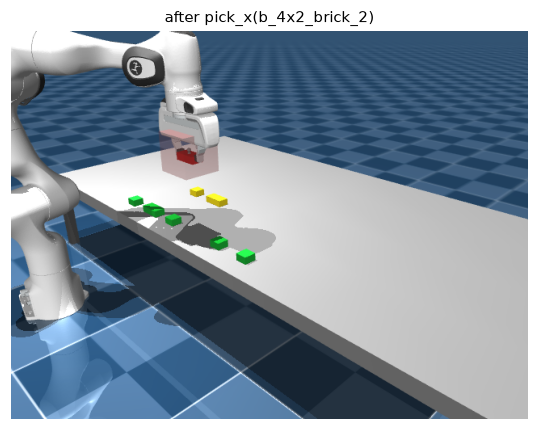

[5/24] place_x(b_4x2_brick_2, b_2x2_brick_1, gap_2, gap_3) -> ok


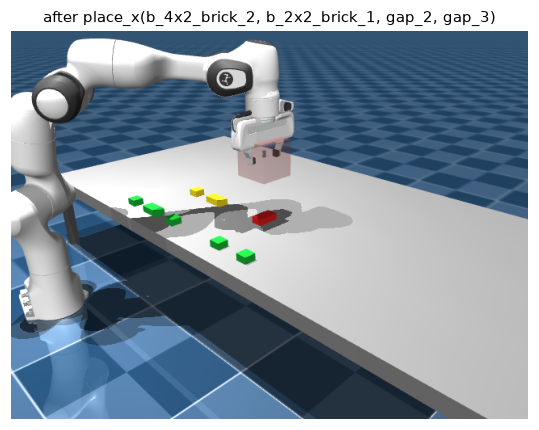

[6/24] prepare_place(b_4x2_brick_5, b_4x2_brick_2, filler_2, filler_3, filler_4, filler_5) -> ok


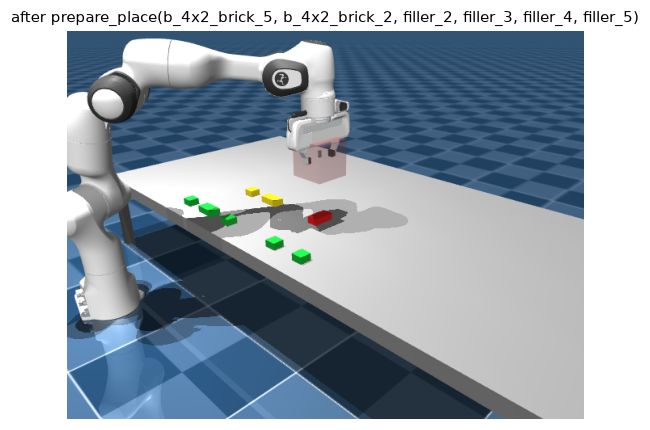

[7/24] prepare_place(b_2x2_brick_8, b_4x2_brick_2, filler_2, filler_3, filler_4, filler_5) -> ok


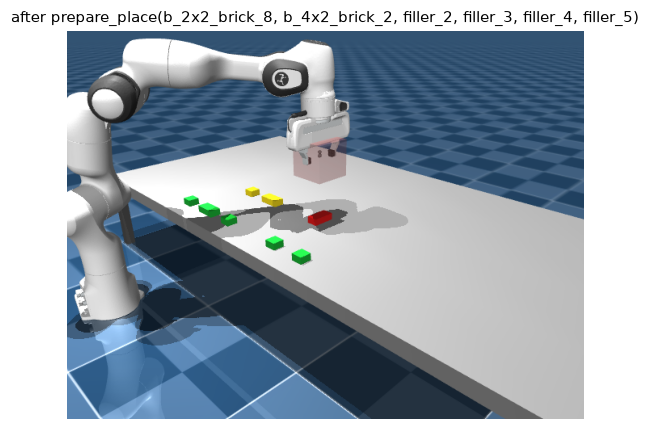

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.1 mm
  pick SUCCESS
[8/24] pick_x(b_2x2_brick_3) -> ok


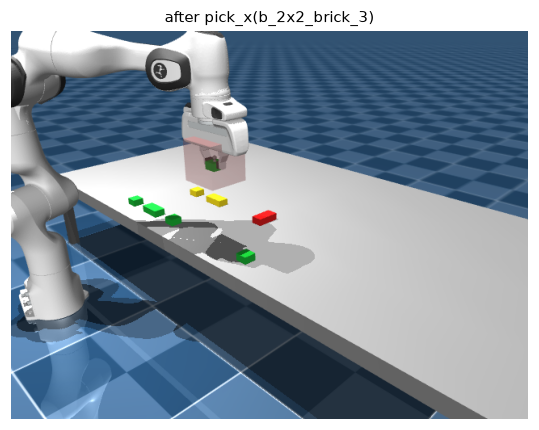

[9/24] place_x(b_2x2_brick_3, b_2x2_brick_1, gap_2, gap_3) -> ok


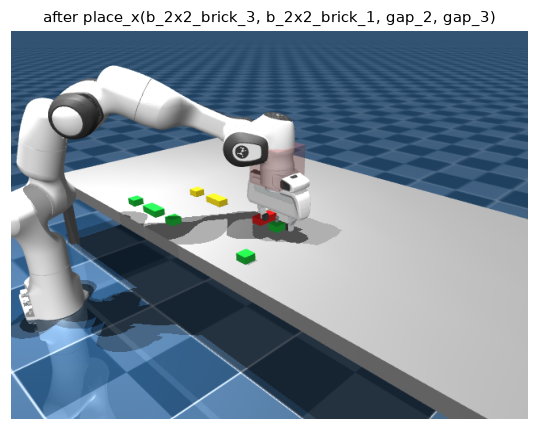

[10/24] prepare_place(b_2x2_brick_6, b_2x2_brick_3, filler_2, filler_3, filler_4, filler_5) -> ok


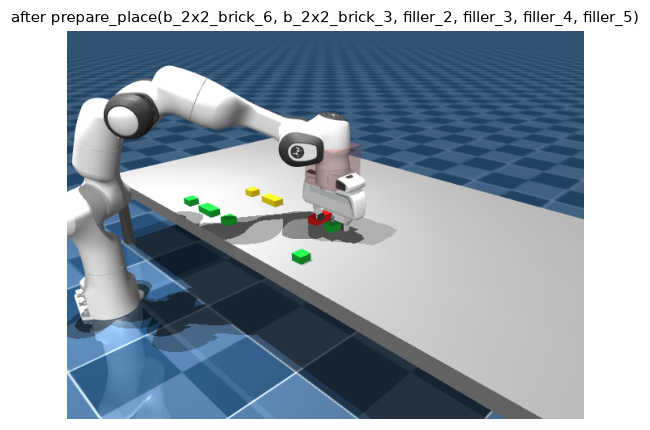

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  approach plan failed — next candidate
[PickPlaceExecutor] Trying candidate 2/2: top_down_y
  approach plan failed — next candidate
[PickPlaceExecutor] All 2 candidates exhausted for 2x2_brick_1
[11/24] pick_y(b_2x2_brick_1) -> FAILED


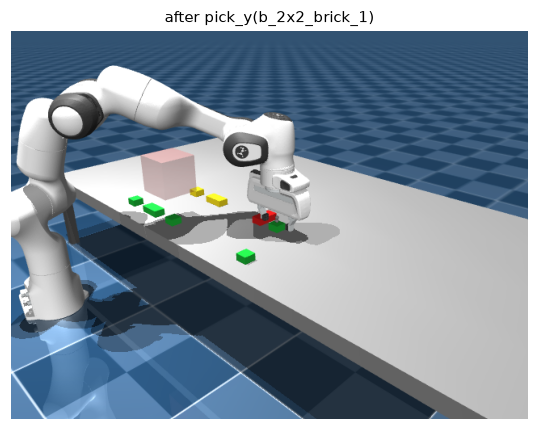


executed: False
succeeded = False


In [5]:
ok, n = True, 0
for i, (name, args) in enumerate(plan):
    success, _ = bridge.execute_action(name, *args)
    print(f"[{i+1}/{len(plan)}] {name}({', '.join(args)}) -> {'ok' if success else 'FAILED'}")
    show_scene(scene.env, f"after {name}({', '.join(args)})")
    if not success:
        ok, n = False, i
        break
else:
    n = len(plan)

print("\nexecuted:", ok)
succeeded, _ = scene.check_goal()
print(f"{succeeded = }")